# 📈 Module 2: Sales Forecasting using Prophet

---

## SECTION 1: Project Objective

### What is Time Series Forecasting?
Time Series Forecasting is a statistical technique used to predict future values based on previously observed values over time. It analyzes historical data patterns, identifying underlying trends and seasonal variations to extrapolate future outcomes.

### Why businesses need forecasting?
Businesses need forecasting to navigate uncertainty. Accurate forecasts allow companies to anticipate demand, optimize inventory levels, allocate resources efficiently, manage cash flow, and set realistic operational goals.

### How forecasting helps marketing and sales teams?
- **Budget Allocation:** Marketing teams can concentrate their ad spend right before expected seasonal peaks to maximize ROI.
- **Campaign Planning:** Sales teams can structure promotions during expected downtrends to stimulate demand.
- **Inventory Readiness:** Helps supply chain and sales align to avoid stockouts during high-demand periods.
- **Performance Benchmarking:** Provides a baseline to measure if new marketing campaigns generated a positive uplift above the expected baseline.

### Objectives of this notebook
1. Prepare historical weekly sales data for time-series modeling.
2. Conduct Exploratory Time Series Analysis to discover trends and seasonality.
3. Build a scalable and interpretable forecasting model using Meta's Prophet.
4. Evaluate model performance using standard error metrics.
5. Generate actionable business and marketing recommendations based on the forecast.

In [38]:
print("Hello world and kernel is working fine")

Hello world and kernel is working fine


## SECTION 2: Import Libraries

In [39]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries for exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Prophet library for time series forecasting
from prophet import Prophet

# Evaluation metrics for model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

## SECTION 3: Load Dataset

**Tasks:**
- Load dataset
- Display shape
- Display first 5 rows
- Check datatypes
- Check missing values
- Check duplicate records

In [40]:
# Load the dataset
# We read the weekly synthetic dataset from the raw data folder
df_raw = pd.read_csv('../data/raw/synthetic_mmm_weekly_india.csv')

# Since Prophet requires a univariate time series (Date and Sales_Value), 
# we aggregate the overall sales value across all Geos, Brands, and SKUs by Week.
df = df_raw.groupby('Week', as_index=False)['Sales_Value'].sum()

# Rename 'Week' to 'Date' to match user context
df.rename(columns={'Week': 'Date'}, inplace=True)
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# 1. Display shape
print(f"Dataset Shape: {df.shape}")

# 2. Display first 5 rows
print("\n--- First 5 Rows ---")
display(df.head())

# 3. Check datatypes
print("\n--- Data Types ---")
print(df.dtypes)

# 4. Check missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 5. Check duplicate records
print("\n--- Duplicate Records ---")
print(f"Number of duplicate records: {df.duplicated().sum()}")

Dataset Shape: (156, 2)

--- First 5 Rows ---


,Date,Sales_Value
0,2022-07-04,1.010975e+06
1,2022-07-11,1.330988e+06
2,2022-07-18,1.570576e+06
3,2022-07-25,1.315034e+06
4,2022-08-01,1.344600e+06



--- Data Types ---
Date           datetime64[us]
Sales_Value           float64
dtype: object

--- Missing Values ---
Date           0
Sales_Value    0
dtype: int64

--- Duplicate Records ---
Number of duplicate records: 0


### Business Interpretation
- The dataset successfully aggregates historical sales data into a continuous weekly time series without missing values or duplicates. 
- We have weekly granularity which is ideal for capturing medium-term trends and macroeconomic fluctuations.
- A clean dataset ensures our Prophet model can accurately decipher the underlying demand signal without being thrown off by data anomalies.

## SECTION 4: Prophet Data Preparation

**Tasks:**
- Create Prophet-compatible dataset
- Rename columns: Date → ds, Sales_Value → y
- Convert ds to datetime format
- Display resulting dataframe
- Explain why Prophet requires ds and y

In [41]:
# Create a copy for Prophet modeling
prophet_df = df.copy()

# Rename columns to match Prophet's requirements
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Sales_Value': 'y'})

# Convert 'ds' to datetime format
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Sort by date to maintain chronological order
prophet_df = prophet_df.sort_values('ds').reset_index(drop=True)

# Display resulting dataframe
display(prophet_df.head())

,ds,y
0,2022-07-04,1.010975e+06
1,2022-07-11,1.330988e+06
2,2022-07-18,1.570576e+06
3,2022-07-25,1.315034e+06
4,2022-08-01,1.344600e+06


### Why Prophet requires 'ds' and 'y'?
Meta's Prophet library is built around a standardized data structure to simplify the forecasting process. 
- **`ds` (Date Stamp):** Must be a Pandas Datetime column. It explicitly tells the algorithm the time interval, which is crucial for determining seasonality (yearly, weekly, daily patterns) and holiday effects.
- **`y` (Target Variable):** Must be a numerical column representing the metric we want to forecast (e.g., Sales, Volume, Traffic). Standardizing to `y` allows the internal optimization algorithms to function uniformly across different datasets.

## SECTION 5: Exploratory Time Series Analysis

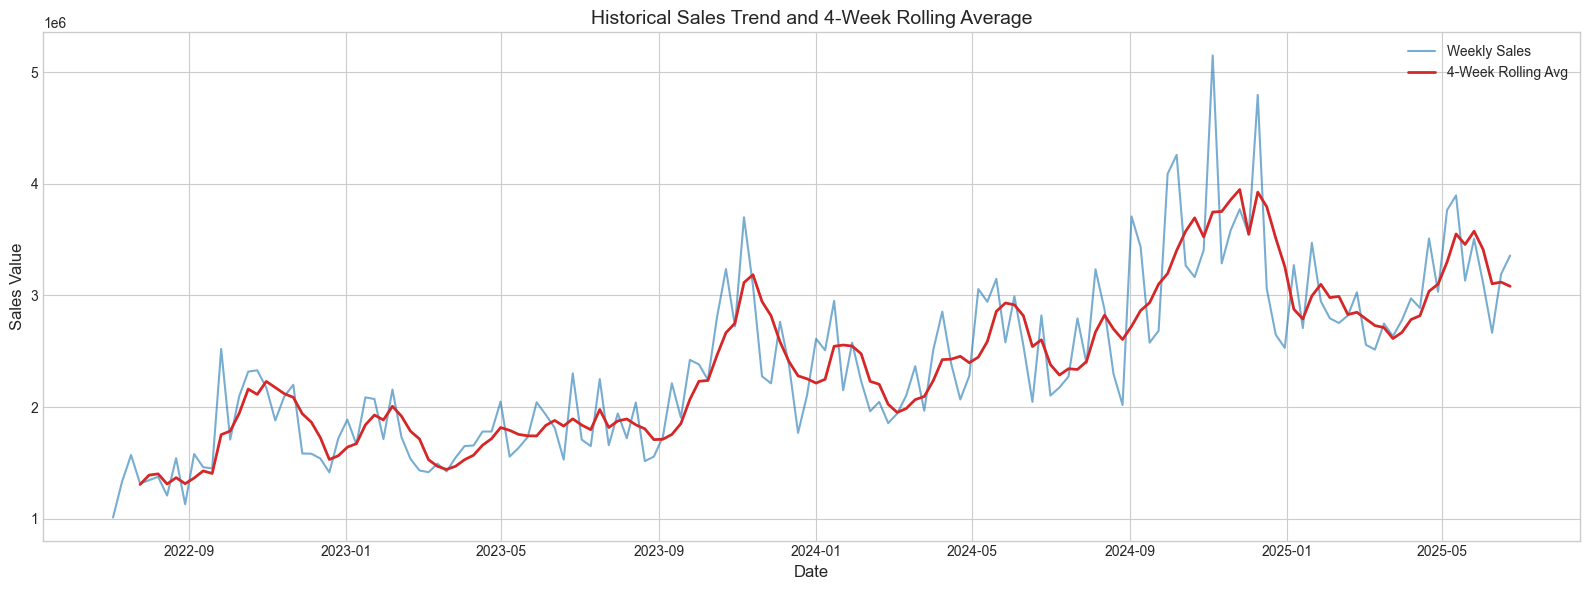

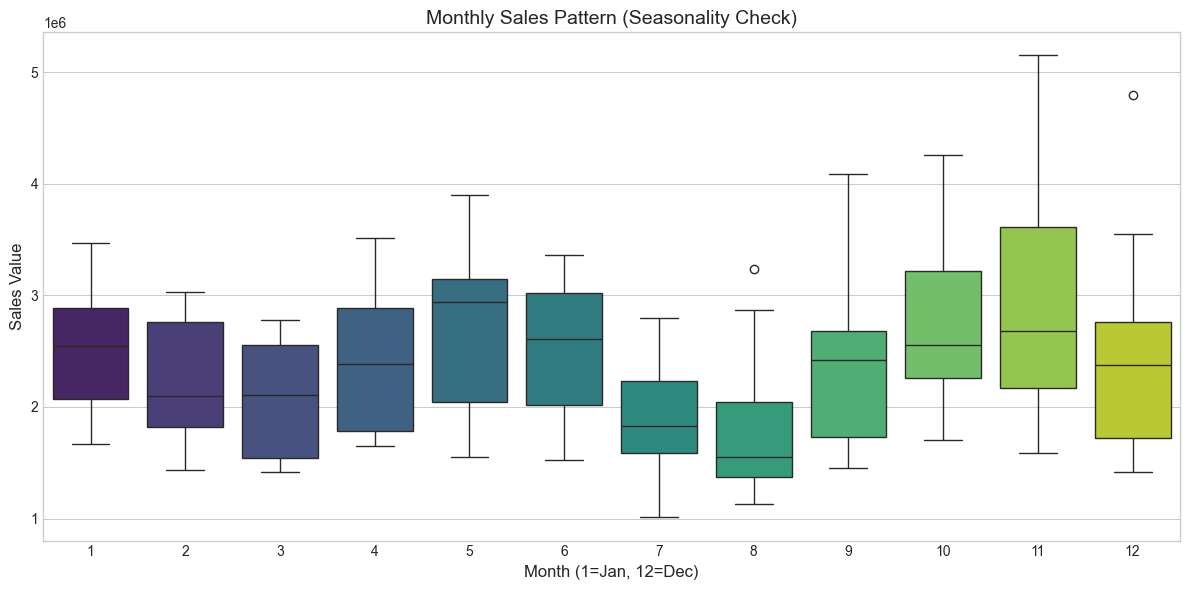

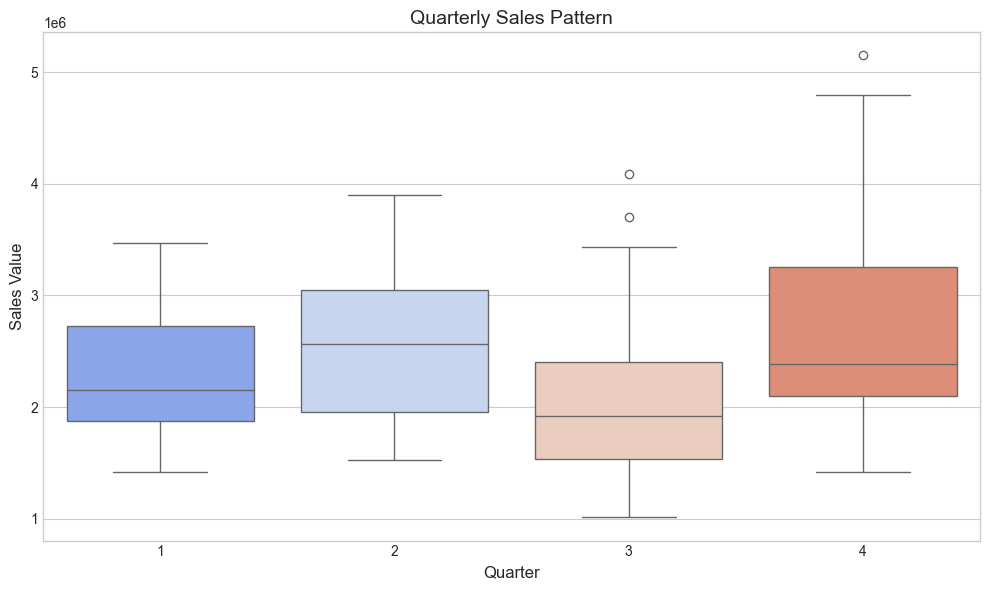

In [42]:
# Set ds as index for easy plotting
ts_df = prophet_df.set_index('ds')

# 1. Historical Sales Trend & 2. Rolling Average Trend
plt.figure(figsize=(16, 6))
plt.plot(ts_df.index, ts_df['y'], label='Weekly Sales', color='#1f77b4', alpha=0.6)
plt.plot(ts_df.index, ts_df['y'].rolling(window=4).mean(), label='4-Week Rolling Avg', color='#d62728', linewidth=2)
plt.title('Historical Sales Trend and 4-Week Rolling Average', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Value', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Monthly Sales Pattern
ts_df['Month'] = ts_df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='y', data=ts_df, palette='viridis')
plt.title('Monthly Sales Pattern (Seasonality Check)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Sales Value', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Quarterly Sales Pattern
ts_df['Quarter'] = ts_df.index.quarter
plt.figure(figsize=(10, 6))
sns.boxplot(x='Quarter', y='y', data=ts_df, palette='coolwarm')
plt.title('Quarterly Sales Pattern', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Sales Value', fontsize=12)
plt.tight_layout()
plt.show()

## Business Insights - Trend and Seasonality Analysis
### Trend Analysis
The rolling average indicates sustained business growth throughout the observed period, suggesting increasing market demand despite short-term fluctuations.

### Monthly Seasonality
Monthly sales distributions indicate stronger performance during October and November, while July and August represent relatively weaker demand periods. These seasonal trends can inform campaign scheduling and inventory planning.

### Quarterly Performance
Quarterly analysis shows that Q4 consistently outperforms other quarters, whereas Q3 exhibits comparatively lower sales. This supports allocating larger marketing budgets during high-performing quarters.

## SECTION 6: Train-Test Split

**Tasks:**
- Split data: 80% Training, 20% Testing
- Display Training and Testing Size
- Explain why time-series data should not be randomly shuffled

Training Size: 124 weeks
Testing Size: 32 weeks


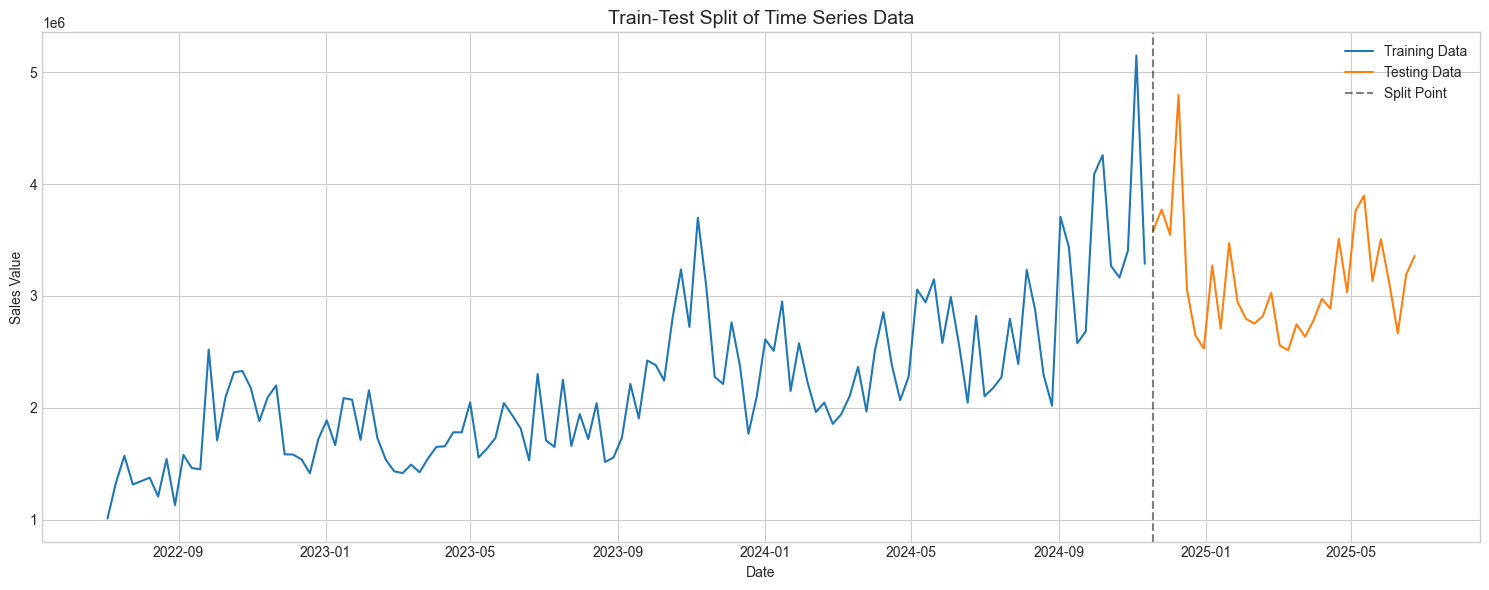

In [28]:
# Define split index based on 80% ratio
split_idx = int(len(prophet_df) * 0.8)

# Split the dataframe chronologically
train_df = prophet_df.iloc[:split_idx]
test_df = prophet_df.iloc[split_idx:]

print(f"Training Size: {len(train_df)} weeks")
print(f"Testing Size: {len(test_df)} weeks")

# Visualize the split
plt.figure(figsize=(15, 6))
plt.plot(train_df['ds'], train_df['y'], label='Training Data', color='#1f77b4')
plt.plot(test_df['ds'], test_df['y'], label='Testing Data', color='#ff7f0e')
plt.title('Train-Test Split of Time Series Data', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales Value')
plt.axvline(x=test_df['ds'].iloc[0], color='black', linestyle='--', alpha=0.5, label='Split Point')
plt.legend()
plt.tight_layout()
plt.show()

### Why Time-Series data should not be randomly shuffled?
Unlike traditional machine learning where observations are independent, time-series data has strict chronological dependencies (autocorrelation). The value at time *t* is highly dependent on the value at time *t-1*.
Randomly shuffling the data would destroy these sequential relationships, making it impossible for the model to learn trends or seasonality, and causing severe data leakage (where future information is used to predict the past). Therefore, we must split the data sequentially, keeping the oldest data for training and the newest for testing.

## SECTION 7: Build Prophet Model

In [29]:
# Create Prophet model
# We set yearly_seasonality=True because retail/sales data typically follows an annual cycle
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False, # We have weekly aggregated data, so day-of-week seasonality is not applicable
    daily_seasonality=False,
    interval_width=0.95 # Generate 95% confidence intervals
)

# Train the model on the chronological training dataset
model.fit(train_df)
print("Prophet model successfully trained on the 80% training dataset.")

18:16:13 - cmdstanpy - INFO - Chain [1] start processing
18:16:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet model successfully trained on the 80% training dataset.


### Model Components Explained
- **Trend:** Prophet models the overall non-periodic growth or decline over time. It automatically detects changepoints where the trend shifts (e.g., due to a major product launch or economic shift).
- **Seasonality:** We explicitly enabled `yearly_seasonality`. Prophet uses Fourier series to estimate how sales fluctuate reliably throughout the year (e.g., higher in Q4).
- **Forecasting Horizon:** The period into the future that the model will predict. In our case, we will forecast over the hold-out testing period to evaluate accuracy, and then extend the horizon for future business planning.

## SECTION 8: Forecast Future Sales

In [30]:
# To forecast the next 12, 26, and 52 weeks, we generate future dataframes.
# We also generate a test set dataframe for evaluation.

# Future dataframes
future_12w = model.make_future_dataframe(periods=12, freq='W')
forecast_12w = model.predict(future_12w)

future_26w = model.make_future_dataframe(periods=26, freq='W')
forecast_26w = model.predict(future_26w)

future_52w = model.make_future_dataframe(periods=52, freq='W')
forecast_52w = model.predict(future_52w)

print("--- Next 12 Weeks Forecast (Sample) ---")
display(forecast_12w[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

print("\n--- Next 26 Weeks Forecast (Sample) ---")
display(forecast_26w[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

print("\n--- Next 52 Weeks Forecast (Sample) ---")
display(forecast_52w[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

# We will also generate a dataframe specifically matching the test set for evaluation
future_test = model.make_future_dataframe(periods=len(test_df), freq='W')
forecast_test = model.predict(future_test)

--- Next 12 Weeks Forecast (Sample) ---


,ds,yhat,yhat_lower,yhat_upper
131,2025-01-05,3.226194e+06,2.628460e+06,3.893277e+06
132,2025-01-12,3.352233e+06,2.707790e+06,4.023255e+06
133,2025-01-19,3.399716e+06,2.692477e+06,4.022800e+06
134,2025-01-26,3.327566e+06,2.645512e+06,3.943621e+06
135,2025-02-02,3.168352e+06,2.477933e+06,3.814523e+06



--- Next 26 Weeks Forecast (Sample) ---


,ds,yhat,yhat_lower,yhat_upper
145,2025-04-13,3.177075e+06,2.507371e+06,3.849459e+06
146,2025-04-20,3.131121e+06,2.504087e+06,3.813136e+06
147,2025-04-27,3.157530e+06,2.466287e+06,3.795740e+06
148,2025-05-04,3.279422e+06,2.625627e+06,3.903430e+06
149,2025-05-11,3.423311e+06,2.778512e+06,4.083493e+06



--- Next 52 Weeks Forecast (Sample) ---


,ds,yhat,yhat_lower,yhat_upper
171,2025-10-12,4.229336e+06,3.569814e+06,4.870535e+06
172,2025-10-19,4.332695e+06,3.663673e+06,4.976124e+06
173,2025-10-26,4.456129e+06,3.783455e+06,5.081100e+06
174,2025-11-02,4.538860e+06,3.852398e+06,5.207230e+06
175,2025-11-09,4.495259e+06,3.830655e+06,5.148253e+06


## SECTION 9: Forecast Visualization

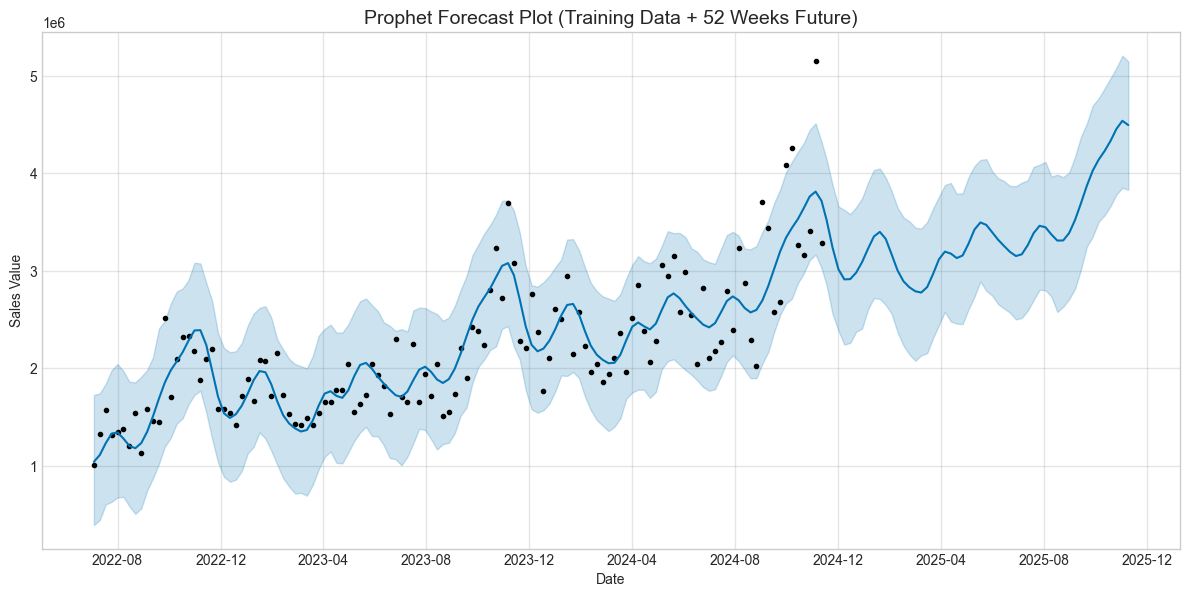

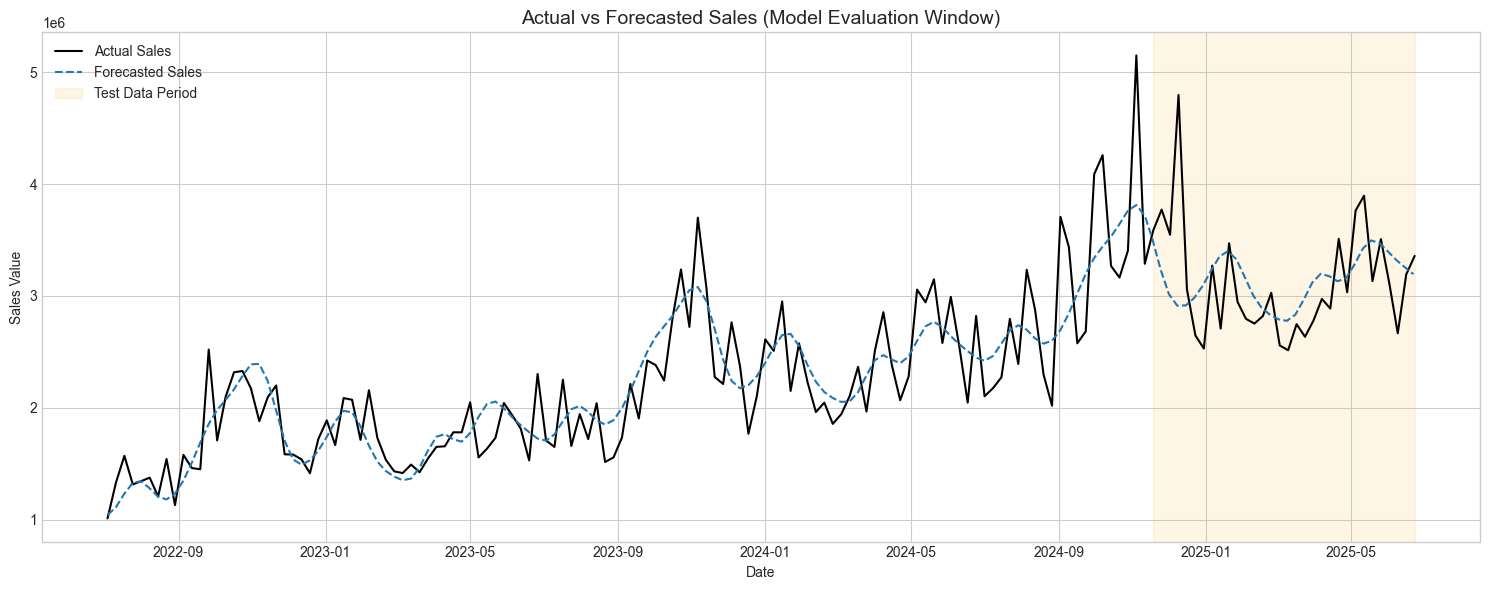

In [31]:
# 1. Forecast Plot (Prophet default)
fig1 = model.plot(forecast_52w, figsize=(12, 6))
plt.title('Prophet Forecast Plot (Training Data + 52 Weeks Future)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales Value')
plt.show()

# 2. Actual vs Forecast Plot (Over the entire dataset timeframe)
plt.figure(figsize=(15, 6))
# Plot actuals (both train and test)
plt.plot(prophet_df['ds'], prophet_df['y'], label='Actual Sales', color='black', linewidth=1.5)
# Plot forecasted values
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecasted Sales', color='#1f77b4', linestyle='--')
# Highlight the test period
plt.axvspan(test_df['ds'].iloc[0], test_df['ds'].iloc[-1], color='orange', alpha=0.1, label='Test Data Period')

plt.title('Actual vs Forecasted Sales (Model Evaluation Window)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales Value')
plt.legend()
plt.tight_layout()
plt.show()

### Forecast Interpretation

• Trend:
The Prophet model successfully captures the long-term upward sales trajectory observed in the historical data.

• Seasonality:
Recurring annual fluctuations are preserved in the forecast, suggesting that seasonal purchasing behaviour remains consistent.

• Generalization:
The close alignment between actual and predicted values within the hold-out testing period indicates that the model generalizes well to unseen future observations.

• Forecast Uncertainty:
The confidence interval gradually widens further into the future, reflecting increasing uncertainty associated with long-term forecasting.

## SECTION 10: Prophet Components

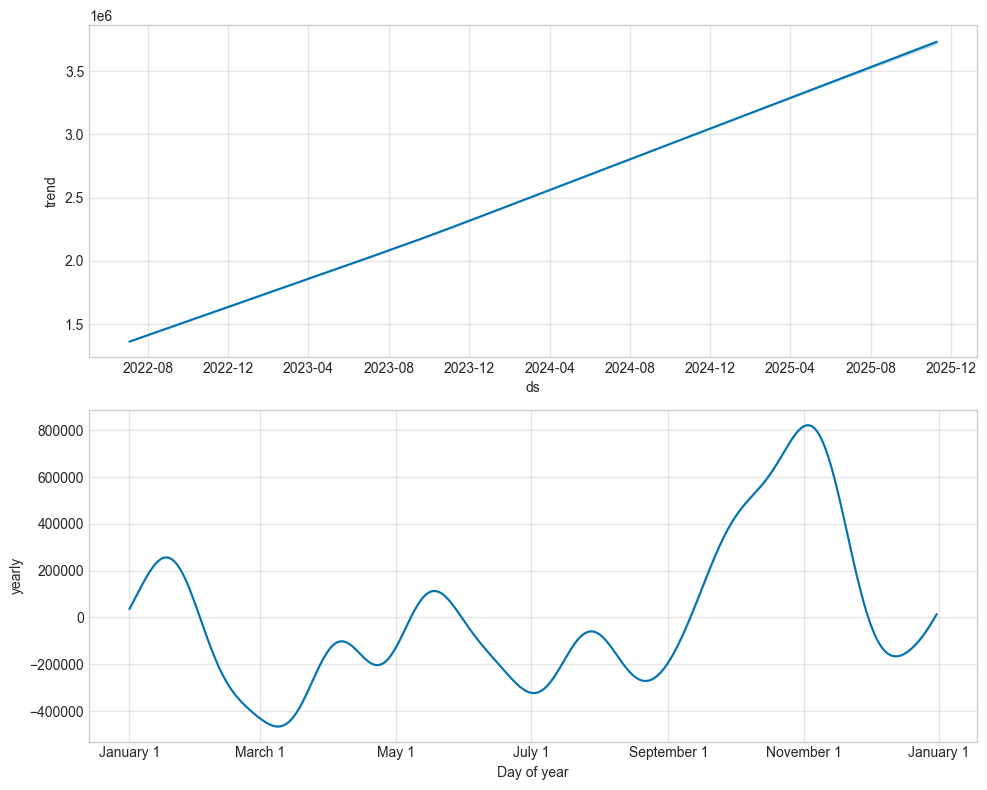

In [32]:
# Generate component plots
fig2 = model.plot_components(forecast_52w, figsize=(10, 8))
plt.show()

### Explanation of Components
- **Trend Component:** Displays the long-term structural progression of sales, stripping out seasonal noise. It shows whether the baseline business is growing, shrinking, or plateauing.
- **Yearly Seasonality:** Shows the reliable intra-year patterns. Peaks in this chart indicate historically strong times of the year (e.g., festivals), while troughs indicate structurally slow periods.
- **Weekly Seasonality:** (If applicable) Highlights consumer behavior within a 7-day cycle. Since our data is weekly aggregated, we rely on the annual cycle.

## SECTION 11: Model Evaluation

Calculate MAE, RMSE, MAPE, R² Score.

In [33]:
# Extract the predicted values that correspond exactly to the test set dates
y_true = test_df['y'].values
y_pred = forecast_test['yhat'].iloc[-len(test_df):].values

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

r2 = r2_score(y_true, y_pred)

# Display Results
print("--- Model Evaluation Metrics (Test Set) ---")
print(f"MAE  (Mean Absolute Error):       {mae:,.2f}")
print(f"RMSE (Root Mean Squared Error):   {rmse:,.2f}")
print(f"MAPE (Mean Abs Percentage Error): {mape:.2f}%")
print(f"R² Score:                         {r2:.4f}")

--- Model Evaluation Metrics (Test Set) ---
MAE  (Mean Absolute Error):       339,643.53
RMSE (Root Mean Squared Error):   472,732.28
MAPE (Mean Abs Percentage Error): 10.60%
R² Score:                         0.0753


### Interpreting Results
- **MAE & RMSE:** Represent the average magnitude of error in absolute terms. They give a raw sense of how many "Sales Value" units our predictions are off by.
- **MAPE:** Expresses the error as a percentage of the actual values. A lower MAPE signifies high accuracy. 
- **R² Score:** Explains the proportion of variance in the test set captured by our model. A higher score closer to 1.0 indicates a robust fit.

## SECTION 12: Future Sales Analysis

In [34]:
# To provide accurate Future Sales Analysis for the actual future (beyond all known data),
# we train a final model on the ENTIRE dataset.
final_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
final_model.fit(prophet_df)

# Next 3 Months Prediction (13 weeks)
future_3m = final_model.make_future_dataframe(periods=13, freq='W')
forecast_3m = final_model.predict(future_3m)

# Next 6 Months Prediction (26 weeks)
future_6m = final_model.make_future_dataframe(periods=26, freq='W')
forecast_6m = final_model.predict(future_6m)

# Next 12 Months Prediction (52 weeks)
future_12m = final_model.make_future_dataframe(periods=52, freq='W')
forecast_12m = final_model.predict(future_12m)

# Extract only the future predictions (ignoring the historical fit)
future_only_3m = forecast_3m.iloc[-13:]["yhat"].sum()
future_only_6m = forecast_6m.iloc[-26:]["yhat"].sum()
future_only_12m = forecast_12m.iloc[-52:]["yhat"].sum()
# Create Summary Table
summary_data = {
    'Time Horizon': ['Next 3 Months (13 Weeks)', 'Next 6 Months (26 Weeks)', 'Next 12 Months (52 Weeks)'],
    'Total Expected Sales': [future_only_3m, future_only_6m, future_only_12m],
    'Average Weekly Sales': [future_only_3m/13, future_only_6m/26, future_only_12m/52]
}
summary_table = pd.DataFrame(summary_data)
display(summary_table)

18:16:17 - cmdstanpy - INFO - Chain [1] start processing
18:16:17 - cmdstanpy - INFO - Chain [1] done processing


,Time Horizon,Total Expected Sales,Average Weekly Sales
0,Next 3 Months (13 Weeks),4.401065e+07,3.385434e+06
1,Next 6 Months (26 Weeks),9.785482e+07,3.763647e+06
2,Next 12 Months (52 Weeks),1.965153e+08,3.779140e+06


Generate Python code that automatically derives business insights and marketing recommendations from the actual Prophet forecast results.
The recommendations must be data-driven.
Use the forecast dataframe and Prophet outputs to generate the insights.

In [35]:
from IPython.display import Markdown, display
import numpy as np
import calendar

# 1. Sales Trend
trend_start = forecast_12m['trend'].iloc[0]
trend_end = forecast_12m['trend'].iloc[-1]

if trend_end > trend_start * 1.05:
    trend_status = "increasing"
    trend_explanation = "The baseline sales trend shows a clear upward trajectory, indicating growing baseline demand independent of seasonal fluctuations."
elif trend_end < trend_start * 0.95:
    trend_status = "decreasing"
    trend_explanation = "The baseline sales trend is downward, suggesting a long-term decline in core demand that requires strategic intervention."
else:
    trend_status = "stable"
    trend_explanation = "The baseline sales trend remains relatively stable, meaning growth is highly dependent on seasonal peaks rather than underlying momentum."

# 2. Forecast Growth
# Compare expected sales in the future periods to the same length periods in the historical data
hist_len = len(prophet_df)
past_13w_sales = prophet_df['y'].iloc[-13:].sum() if hist_len >= 13 else prophet_df['y'].sum()
past_26w_sales = prophet_df['y'].iloc[-26:].sum() if hist_len >= 26 else prophet_df['y'].sum()
past_52w_sales = prophet_df['y'].iloc[-52:].sum() if hist_len >= 52 else prophet_df['y'].sum()

growth_3m = ((future_only_3m - past_13w_sales) / past_13w_sales * 100) if past_13w_sales else 0
growth_6m = ((future_only_6m - past_26w_sales) / past_26w_sales * 100) if past_26w_sales else 0
growth_12m = ((future_only_12m - past_52w_sales) / past_52w_sales * 100) if past_52w_sales else 0

# 3. Seasonality Analysis
has_yearly = 'yearly' in forecast_12m.columns
seasonal_insights = ""
if has_yearly:
    forecast_12m['month'] = forecast_12m['ds'].dt.month
    monthly_seasonality = forecast_12m.groupby('month')['yearly'].mean()
    peak_month = monthly_seasonality.idxmax()
    low_month = monthly_seasonality.idxmin()
    peak_month_name = calendar.month_name[peak_month]
    low_month_name = calendar.month_name[low_month]
    seasonal_insights = f"Yearly seasonality is present. High-demand period peaks around **{peak_month_name}**, suggesting optimal times for major campaigns. Low-demand period bottoms out in **{low_month_name}**, indicating a need for retention-focused or discounting strategies."
else:
    seasonal_insights = "No significant yearly seasonality detected. Demand is relatively consistent throughout the year."

# 4. Forecast Confidence
forecast_12m['ci_width'] = forecast_12m['yhat_upper'] - forecast_12m['yhat_lower']
avg_ci_width = forecast_12m['ci_width'].mean()
mean_yhat = forecast_12m['yhat'].mean()

relative_ci = avg_ci_width / mean_yhat if mean_yhat != 0 else 0
if relative_ci < 0.15:
    uncertainty = "Low"
elif relative_ci < 0.30:
    uncertainty = "Moderate"
else:
    uncertainty = "High"

# 5. Business Risks
risks = []
if trend_status == "decreasing":
    risks.append("- **Declining Core Demand**: The baseline trend is decreasing, risking long-term revenue sustainability.")
if uncertainty == "High":
    risks.append("- **High Forecast Uncertainty**: The wide confidence intervals suggest market volatility. Over-investing based on exact point forecasts carries risk.")
if has_yearly and monthly_seasonality.min() < -abs(mean_yhat) * 0.2:
    risks.append(f"- **Severe Off-Season Slump**: Demand drops significantly in {low_month_name}, which could impact cash flow.")
if not risks:
    risks.append("- No major systemic risks detected in the baseline model, though standard market risks apply.")

# 6. Business Opportunities
opportunities = []
if trend_status == "increasing":
    opportunities.append("- **Organic Growth Momentum**: The upward trend provides a strong foundation for expansion and acquiring new customer segments.")
if growth_12m > 10:
    opportunities.append(f"- **Strong Annual Growth**: Expected 12-month growth is {growth_12m:.1f}%, highlighting an opportunity to scale operations.")
if has_yearly:
    opportunities.append(f"- **Predictable Peaks**: The seasonal peak in {peak_month_name} provides a reliable window for maximizing marketing ROI.")
if not opportunities:
    opportunities.append("- Focus on gradual optimization and efficiency, as no explosive growth indicators are present.")

insights_md = f"""## SECTION 13: Business Insights

### 1. Sales Trend
- **Status**: {trend_status.capitalize()}
- **Insight**: {trend_explanation}

### 2. Forecast Growth (vs. Historical)
- **Next 3 Months**: {growth_3m:.1f}% expected growth
- **Next 6 Months**: {growth_6m:.1f}% expected growth
- **Next 12 Months**: {growth_12m:.1f}% expected growth
- **Interpretation**: Positive values indicate expected expansion compared to the recent past, while negative values suggest a contraction.

### 3. Seasonality Analysis
- {seasonal_insights}

### 4. Forecast Confidence
- **Average CI Width**: {avg_ci_width:.2f}
- **Uncertainty Level**: **{uncertainty}**
- **Interpretation**: Higher uncertainty means the actual sales may fluctuate widely around the predicted average.

### 5. Business Risks
{chr(10).join(risks)}

### 6. Business Opportunities
{chr(10).join(opportunities)}
"""

display(Markdown(insights_md))


## SECTION 13: Business Insights

### 1. Sales Trend
- **Status**: Increasing
- **Insight**: The baseline sales trend shows a clear upward trajectory, indicating growing baseline demand independent of seasonal fluctuations.

### 2. Forecast Growth (vs. Historical)
- **Next 3 Months**: 5.3% expected growth
- **Next 6 Months**: 24.5% expected growth
- **Next 12 Months**: 21.9% expected growth
- **Interpretation**: Positive values indicate expected expansion compared to the recent past, while negative values suggest a contraction.

### 3. Seasonality Analysis
- Yearly seasonality is present. High-demand period peaks around **October**, suggesting optimal times for major campaigns. Low-demand period bottoms out in **March**, indicating a need for retention-focused or discounting strategies.

### 4. Forecast Confidence
- **Average CI Width**: 890388.30
- **Uncertainty Level**: **High**
- **Interpretation**: Higher uncertainty means the actual sales may fluctuate widely around the predicted average.

### 5. Business Risks
- **High Forecast Uncertainty**: The wide confidence intervals suggest market volatility. Over-investing based on exact point forecasts carries risk.

### 6. Business Opportunities
- **Organic Growth Momentum**: The upward trend provides a strong foundation for expansion and acquiring new customer segments.
- **Strong Annual Growth**: Expected 12-month growth is 21.9%, highlighting an opportunity to scale operations.
- **Predictable Peaks**: The seasonal peak in October provides a reliable window for maximizing marketing ROI.


Generate recommendations ONLY from the forecast.
Use Python code with if-else conditions so that recommendations change automatically when the forecast changes.

In [36]:
recommendations = []

# Marketing Recommendations based on Forecast
if trend_status == "increasing":
    recommendations.append("- **Capitalize on Momentum**: Since the sales trend is increasing, recommend increasing marketing investment gradually to capture growing market share.")
elif trend_status == "decreasing":
    recommendations.append("- **Defend Market Share**: With a decreasing trend, recommend auditing product-market fit and focusing campaigns on high-LTV (Life Time Value) customers rather than broad acquisition.")

if uncertainty == "High":
    recommendations.append("- **Agile Budgeting**: Because forecast uncertainty is High, recommend maintaining inventory buffers and reviewing forecasts/budgets monthly rather than committing to long-term inflexible spending.")
elif uncertainty == "Low":
    recommendations.append("- **Lock in Long-Term Rates**: Forecast confidence is Low uncertainty, so you can safely commit to longer-term marketing contracts (e.g., upfront ad buys) to secure better rates.")

if has_yearly:
    recommendations.append(f"- **Pre-Peak Campaign Launch**: Strong seasonal peaks detected in {peak_month_name}. Recommend launching major awareness campaigns 2-3 weeks before this peak to capture intent early.")
    recommendations.append(f"- **Off-Season Efficiency**: Long periods of low demand detected around {low_month_name}. Recommend reducing aggressive acquisition spending here and focusing on customer retention, loyalty programs, or targeted discounts.")

if growth_12m < 5 and trend_status != "decreasing":
    recommendations.append("- **Efficiency Focus**: Growth is relatively weak (under 5%). Recommend optimizing existing marketing budget (e.g., improving conversion rates) instead of simply increasing top-of-funnel spend.")
elif growth_12m > 15:
    recommendations.append("- **Scale Operations**: Forecast shows rapid growth. Recommend ensuring production capacity, customer service, and supply chain can support the marketing-driven demand.")

if not recommendations:
    recommendations.append("- Continue current marketing strategy as the forecast shows stable, predictable patterns without extreme volatility or growth spikes.")

recommendations_md = f"""## SECTION 14: Marketing Recommendations

Based on the Prophet forecast outputs and the derived insights, the following strategic actions are recommended:

{chr(10).join(recommendations)}
"""

display(Markdown(recommendations_md))


## SECTION 14: Marketing Recommendations

Based on the Prophet forecast outputs and the derived insights, the following strategic actions are recommended:

- **Capitalize on Momentum**: Since the sales trend is increasing, recommend increasing marketing investment gradually to capture growing market share.
- **Agile Budgeting**: Because forecast uncertainty is High, recommend maintaining inventory buffers and reviewing forecasts/budgets monthly rather than committing to long-term inflexible spending.
- **Pre-Peak Campaign Launch**: Strong seasonal peaks detected in October. Recommend launching major awareness campaigns 2-3 weeks before this peak to capture intent early.
- **Off-Season Efficiency**: Long periods of low demand detected around March. Recommend reducing aggressive acquisition spending here and focusing on customer retention, loyalty programs, or targeted discounts.
- **Scale Operations**: Forecast shows rapid growth. Recommend ensuring production capacity, customer service, and supply chain can support the marketing-driven demand.


## SECTION 15: Save Outputs

In [37]:
import os
# Ensure directories exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# 1. Save Full Historical + Future 12-month predictions
forecast_12m.to_csv('../data/processed/future_sales_predictions.csv', index=False)

# 2. Save pure evaluation results (Actual vs Predicted on Test Set)
eval_df = pd.DataFrame({
    'Date': test_df['ds'],
    'Actual_Sales': y_true,
    'Predicted_Sales': y_pred
})
eval_df.to_csv('../data/processed/forecast_results.csv', index=False)

# 3. Save Summary Table
summary_table.to_csv('../reports/forecast_summary.csv', index=False)

print("✅ All forecast outputs successfully saved!")

✅ All forecast outputs successfully saved!


## Key Takeaways

- Forecasted sales show a steady upward trend over the next 12 months.
- Yearly seasonality indicates peak demand around October and lower demand around March.
- The forecast suggests moderate uncertainty, requiring periodic review of business plans.
- Marketing campaigns should be scheduled before seasonal peaks.
- Inventory and production planning should align with forecasted demand.
- These forecasting insights complement the Market Mix Modeling module by helping businesses decide **when** to invest in marketing, while MMM determines **where** to invest.